# Preprocessing and Model Building

### Importing libraries


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.metrics import(

        accuracy_score,
        balanced_accuracy_score,
        f1_score,
        precision_score,
        recall_score,
        roc_auc_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
        roc_curve
)


# Preprocessing

In [14]:
df = pd.read_csv('customer_churn_feature.csv')
df.head(5)

,customer_id,identity_segment,age,income,group_size,location,preferred_price_tier,preferred_rest_type,total_spend,avg_order_value,...,unique_restaurants,unique_cuisines,unique_rest_types,restaurant_loyalty,cuisine_loyalty,avg_actual_group_size,std_group_size,avg_price_deviation,rest_type_match_rate,churned
0,1000001,Couple,43,59373,1,Whitefield,Mid-range,Fine Dining,2052.3801,684.126678,...,3,3,3,0.333333,0.333333,1.0,0.0,223.186676,0.333333,0
1,1000002,Office Worker,36,87255,2,HSR,Budget,Cafe,8202.4990,630.961535,...,13,13,3,0.076923,0.076923,2.0,0.0,297.756919,0.846154,1
2,1000003,Couple,28,102362,3,Koramangala 5th Block,Mid-range,Cafe,14056.7010,669.366669,...,21,17,5,0.047619,0.190476,3.0,0.0,350.020945,0.809524,1
3,1000004,Family,55,178855,7,Indiranagar,Mid-range,Casual Dining,10220.6600,567.814441,...,18,18,3,0.055556,0.055556,7.0,0.0,167.776671,0.833333,1
4,1000005,Student,24,20379,3,Bannerghatta Road,Budget,Beverage Shop,1250.0300,312.507505,...,4,3,3,0.250000,0.500000,3.0,0.0,138.842499,0.500000,1


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9258 entries, 0 to 9257
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            9258 non-null   int64  
 1   identity_segment       9258 non-null   object 
 2   age                    9258 non-null   int64  
 3   income                 9258 non-null   int64  
 4   group_size             9258 non-null   int64  
 5   location               9258 non-null   object 
 6   preferred_price_tier   9258 non-null   object 
 7   preferred_rest_type    9258 non-null   object 
 8   total_spend            9258 non-null   float64
 9   avg_order_value        9258 non-null   float64
 10  median_order_value     9258 non-null   float64
 11  std_order_value        8486 non-null   float64
 12  max_order_value        9258 non-null   float64
 13  recency_days           9258 non-null   float64
 14  mean_order_gap         8486 non-null   float64
 15  std_

In [8]:
df.describe()

,customer_id,age,income,group_size,total_spend,avg_order_value,median_order_value,std_order_value,max_order_value,recency_days,...,unique_restaurants,unique_cuisines,unique_rest_types,restaurant_loyalty,cuisine_loyalty,avg_actual_group_size,std_group_size,avg_price_deviation,rest_type_match_rate,churned
count,9.258000e+03,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,8486.000000,9258.000000,9258.000000,...,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,8486.0,9258.000000,9258.000000,9258.000000
mean,1.005001e+06,30.436487,70618.655001,1.916721,7747.708253,655.725630,617.167704,299.370276,1149.942404,27.025059,...,11.144956,9.187730,2.757183,0.266146,0.331938,1.916721,0.0,286.139945,0.746170,0.413588
std,2.886728e+03,8.781438,42353.173259,1.268135,11655.660706,384.962658,386.214981,228.283370,751.470191,27.509787,...,13.324964,9.905221,1.965242,0.272020,0.266530,1.268135,0.0,219.442985,0.266421,0.492503
min,1.000001e+06,18.000000,10012.000000,1.000000,76.380000,76.379997,76.379997,0.367688,76.380000,0.000000,...,1.000000,1.000000,1.000000,0.009709,0.032258,1.000000,0.0,0.279999,0.000000,0.000000
25%,1.002502e+06,23.000000,32989.500000,1.000000,1767.829975,405.716247,373.727497,161.914528,654.985000,3.900002,...,3.000000,3.000000,1.000000,0.083333,0.142857,1.000000,0.0,148.710000,0.640000,0.000000
50%,1.005004e+06,29.000000,66183.500000,1.000000,4046.559800,548.385005,510.695007,231.739087,935.015000,14.599998,...,7.000000,6.000000,2.000000,0.166667,0.250000,1.000000,0.0,220.481068,0.808365,0.000000
75%,1.007496e+06,37.000000,96706.750000,2.000000,8911.889250,758.964668,704.085022,352.573521,1379.440000,48.299999,...,13.750000,12.000000,4.000000,0.333333,0.500000,2.000000,0.0,349.380438,1.000000,1.000000
max,1.010000e+06,55.000000,179979.000000,10.000000,162073.050000,3513.290039,3513.290039,2189.789441,7030.450000,89.800000,...,103.000000,77.000000,17.000000,1.000000,1.000000,10.000000,0.0,2729.629883,1.000000,1.000000


In [10]:
df.isna().sum()

customer_id                 0
identity_segment            0
age                         0
income                      0
group_size                  0
location                    0
preferred_price_tier        0
preferred_rest_type         0
total_spend                 0
avg_order_value             0
median_order_value          0
std_order_value           772
max_order_value             0
recency_days                0
mean_order_gap            772
std_order_gap            1647
min_order_gap             772
max_order_gap             772
orders_first_30d            0
orders_middle_30d           0
orders_last_30d             0
orders_last_7d              0
orders_last_14d             0
spend_first_30d           901
spend_middle_30d         2195
spend_last_30d           3296
unique_restaurants          0
unique_cuisines             0
unique_rest_types           0
restaurant_loyalty          0
cuisine_loyalty             0
avg_actual_group_size       0
std_group_size            772
avg_price_

In [13]:
print(df['churned'].value_counts())
print(df['churned'].value_counts(normalize=True))

churned
0    5429
1    3829
Name: count, dtype: int64
churned
0    0.586412
1    0.413588
Name: proportion, dtype: float64


In [17]:
df[df.isna().any(axis=1)].head()

,customer_id,identity_segment,age,income,group_size,location,preferred_price_tier,preferred_rest_type,total_spend,avg_order_value,...,unique_restaurants,unique_cuisines,unique_rest_types,restaurant_loyalty,cuisine_loyalty,avg_actual_group_size,std_group_size,avg_price_deviation,rest_type_match_rate,churned
3,1000004,Family,55,178855,7,Indiranagar,Mid-range,Casual Dining,10220.66,567.814441,...,18,18,3,0.055556,0.055556,7.0,0.0,167.776671,0.833333,1
4,1000005,Student,24,20379,3,Bannerghatta Road,Budget,Beverage Shop,1250.03,312.507505,...,4,3,3,0.250000,0.500000,3.0,0.0,138.842499,0.500000,1
6,1000007,Couple,24,83088,3,Koramangala 1st Block,Mid-range,Microbrewery,25022.68,1471.922342,...,12,5,2,0.117647,0.529412,3.0,0.0,610.503518,0.823529,1
10,1000012,Food Explorer,29,80265,1,Ejipura,Budget,Quick Bites,1386.72,462.239990,...,3,3,1,0.333333,0.333333,1.0,0.0,274.239990,1.000000,0
13,1000017,Family,27,64183,6,Frazer Town,Mid-range,Fine Dining,4860.38,972.075995,...,2,2,1,0.800000,0.800000,6.0,0.0,583.507990,1.000000,1


### Investigating all the columns with missing values

1. first looking at columns with same number of missing values 


In [22]:
df.loc[df['std_order_value'].isna(), ["customer_id", "total_spend", "avg_order_value", "std_order_value"]].head(20)

,customer_id,total_spend,avg_order_value,std_order_value
8486,1004634,2011.54,2011.540039,NaN
8487,1004276,1151.09,1151.089966,NaN
8488,1009135,203.46,203.460007,NaN
8489,1002703,578.52,578.520020,NaN
8490,1007619,670.37,670.369995,NaN
8491,1001300,473.51,473.510010,NaN
8492,1000649,523.17,523.169983,NaN
8493,1002744,326.80,326.799988,NaN
8494,1006695,192.51,192.509995,NaN
8495,1009402,1023.02,1023.020020,NaN


In [26]:
df.loc[df['mean_order_gap'].isna(), ["customer_id", "total_spend", "avg_order_value", "std_order_value"]].head(5)

,customer_id,total_spend,avg_order_value,std_order_value
8486,1004634,2011.54,2011.540039,NaN
8487,1004276,1151.09,1151.089966,NaN
8488,1009135,203.46,203.460007,NaN
8489,1002703,578.52,578.520020,NaN
8490,1007619,670.37,670.369995,NaN


In [27]:
df.loc[df['min_order_gap'].isna(), ["customer_id", "total_spend", "avg_order_value", "std_order_value"]].head(5)

,customer_id,total_spend,avg_order_value,std_order_value
8486,1004634,2011.54,2011.540039,NaN
8487,1004276,1151.09,1151.089966,NaN
8488,1009135,203.46,203.460007,NaN
8489,1002703,578.52,578.520020,NaN
8490,1007619,670.37,670.369995,NaN


In [29]:
df.loc[df['max_order_gap'].isna(), ["customer_id", "total_spend", "avg_order_value", "std_order_value"]].head(5)

,customer_id,total_spend,avg_order_value,std_order_value
8486,1004634,2011.54,2011.540039,NaN
8487,1004276,1151.09,1151.089966,NaN
8488,1009135,203.46,203.460007,NaN
8489,1002703,578.52,578.520020,NaN
8490,1007619,670.37,670.369995,NaN


In [30]:
df.loc[df['std_order_gap'].isna(), ["customer_id", "total_spend", "avg_order_value", "std_order_value"]].head(5)

,customer_id,total_spend,avg_order_value,std_order_value
23,1000027,653.16003,326.580002,75.391743
30,1000035,1041.15000,520.575005,390.669429
66,1000076,974.52000,487.259995,87.921655
71,1000081,1290.47000,645.234985,56.052368
74,1000084,723.17004,361.585007,67.281206


reason for null in std_order_gap

* 1 order → no gap → NaN
* 2 orders → one gap → standard deviation can't really be calculated → NaN
* 3+ orders → multiple gaps → standard deviation can be calculated

2. Rest of the columns with missing values

In [15]:
cols = [
        "spend_first_30d",
        "spend_middle_30d",
        "spend_last_30d"
]

df[cols] = df[cols].fillna(0)

# as std_group_size won't contribute much to the model also customer_id for training the model
df.drop(columns = ['std_group_size', 'customer_id'], inplace= True )


30-day spending NaNs

spend_first_30d, spend_middle_30d, and spend_last_30d are NaN when a customer placed no orders during that particular 30-day period.
Since no orders means no spending, these should be treated as 0, not as a missing/unknown value.

std_group_size

Measures how much the customer's order group size varies across orders.
It is not especially useful for our churn problem because there is no strong business reason or churn mechanism connecting group-size variability to churn.
Also, it becomes NaN for customers with insufficient orders to calculate standard deviation.
Therefore, we can drop std_group_size and keep the more interpretable avg_actual_group_size.

The NaNs represent genuine lack of information, not random missing data.
XGBoost can handle missing numerical values natively, so we don't need to replace them with artificial values except for spend columns
This also avoids unnecessary imputation and potential train/test leakage.

# Training the model


In [16]:
#creating the split

X = df.drop(columns='churned')
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [17]:
# encoding the categorical columns

categorical_cols = [
        "identity_segment",
        "location",
        "preferred_price_tier",
        "preferred_rest_type" 
]

X_train = pd.get_dummies(X_train,
                         columns=categorical_cols,
                         dtype=int
                        )

X_test = pd.get_dummies(X_test,
                        columns=categorical_cols,
                        dtype=int
                       )

#Making X_test have the same columns as X_train. If a column exists in training but not in test, put 0
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [45]:
print(X_train.shape)
print(X_test.shape)

(6480, 153)
(2778, 153)


### Building Baseline Model

In [18]:
# Creating basic xgboost model

model = XGBClassifier(objective="binary:logistic", random_state = 42)

model.fit(X_train, y_train)
test_accuracy = model.score(X_test,y_test)
train_accuracy = model.score(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f'Model accuracy:{test_accuracy}')
print(f'training accuracy:{train_accuracy}')
print(f'AUC_ROC_score:{roc_auc_score(y_test, y_prob)}')

Model accuracy:0.8696904247660188
training accuracy:0.996141975308642
AUC_ROC_score:0.9217223079721818


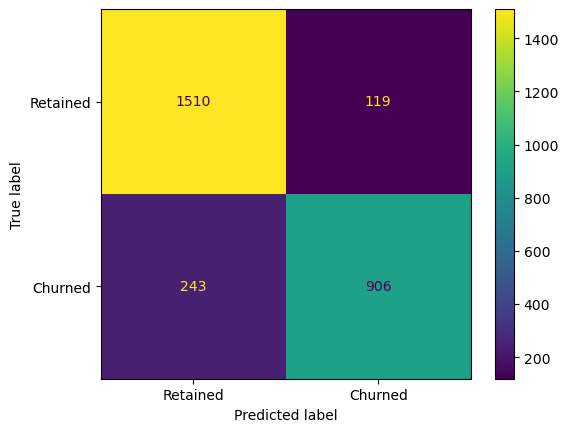

In [20]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm,
                    display_labels=['Retained', 'Churned']).plot()
plt.savefig("../images/confusionmatrix_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

#### Baseline Model

- The baseline XGBoost model achieved **86.97% test accuracy**, but its **99.61% training accuracy** indicates significant overfitting.
- From the confusion matrix, the model has **243 false negatives**, resulting in a recall of approximately **78.9%**.
- This means the baseline model misses around **21% of actual churners**, so improving recall is important for identifying more customers at risk of churn.

### Tuning Hyperparameter 

- **RandomizedSearchCV:** Randomly explores a wide range of hyperparameter combinations to efficiently identify a promising region of parameters.

In [56]:
param_dist = {
    'n_estimators' : [20, 30, 50, 80, 100, 150, 200, 250],
    'max_depth' : [2,3,4,5,8,16],
    'learning_rate' :[0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3], # helps with class imbalance 
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 0.5]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='aucpr', random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=5,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)
print("Best parameters found:")
print(search.best_params_)

print("\nBest cross-validation score (average precision):")
print(search.best_score_)

best_model = search.best_estimator_

results_df = pd.DataFrame(search.cv_results_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:
{'subsample': 0.6, 'scale_pos_weight': 2, 'n_estimators': 80, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}

Best cross-validation score (average precision):
0.9295828505687075


In [57]:
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_scale_pos_weight,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,...,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.495670,0.056283,0.058646,0.002490,0.9,2,50,1,4,0.10,...,0.8,"{'subsample': 0.9, 'scale_pos_weight': 2, 'n_e...",0.932995,0.933855,0.924391,0.933479,0.920291,0.929002,0.005598,4
1,2.593578,0.064892,0.066817,0.004842,0.8,1,250,10,16,0.01,...,0.8,"{'subsample': 0.8, 'scale_pos_weight': 1, 'n_e...",0.932422,0.933495,0.924744,0.932319,0.918642,0.928325,0.005763,8
2,0.912173,0.031240,0.058187,0.000975,0.8,2,80,10,8,0.01,...,0.8,"{'subsample': 0.8, 'scale_pos_weight': 2, 'n_e...",0.930541,0.932886,0.924158,0.932051,0.918555,0.927638,0.005478,13
3,2.123541,0.077184,0.065830,0.003228,0.9,2,200,10,16,0.30,...,1.0,"{'subsample': 0.9, 'scale_pos_weight': 2, 'n_e...",0.916700,0.922544,0.914327,0.919969,0.908124,0.916333,0.004967,49
4,1.599986,0.064172,0.062258,0.002542,1.0,3,250,5,5,0.05,...,0.8,"{'subsample': 1.0, 'scale_pos_weight': 3, 'n_e...",0.927817,0.930142,0.922896,0.929955,0.917401,0.925642,0.004879,20
5,1.146951,0.075342,0.063774,0.004448,0.9,1,250,5,3,0.20,...,0.7,"{'subsample': 0.9, 'scale_pos_weight': 1, 'n_e...",0.923457,0.924697,0.918071,0.922571,0.911312,0.920021,0.004895,40
6,0.494839,0.006790,0.058732,0.004307,0.8,2,80,1,3,0.10,...,0.9,"{'subsample': 0.8, 'scale_pos_weight': 2, 'n_e...",0.933566,0.932490,0.924734,0.933880,0.919626,0.928859,0.005706,5
7,0.413858,0.010614,0.064431,0.015412,0.7,1,80,3,2,0.30,...,0.6,"{'subsample': 0.7, 'scale_pos_weight': 1, 'n_e...",0.925861,0.930472,0.921871,0.927593,0.919929,0.925145,0.003816,21
8,0.997583,0.018038,0.060569,0.001542,0.8,3,80,1,8,0.10,...,0.8,"{'subsample': 0.8, 'scale_pos_weight': 3, 'n_e...",0.926167,0.930186,0.918205,0.928261,0.914699,0.923504,0.005999,25
9,0.316473,0.007479,0.059695,0.001513,0.9,1,30,3,4,0.01,...,0.7,"{'subsample': 0.9, 'scale_pos_weight': 1, 'n_e...",0.929506,0.930551,0.920882,0.930929,0.919033,0.926180,0.005135,19


- **GridSearchCV:** Using it to xxhaustively tests selected parameter combinations around the promising region found via RandomizedSearchCV to firther refine the model.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_dist = {
    'n_estimators' : [75,80,85],
    'max_depth' : [3,4,5],
    'learning_rate' :[0.04, 0.05, 0.06],
    'subsample': [0.4,0.5,0.6],
    'colsample_bytree': [0.4,0.5,0.6],
    "gamma": [0,0.1,0.2]
}

search = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='aucpr', random_state=42),
    param_grid=param_dist,
    scoring='average_precision',
    cv=5,
    verbose=1
)

search.fit(X_train, y_train)
print("Best parameters found:")
print(search.best_params_)

print("\nBest cross-validation score (average precision):")
print(search.best_score_)


best_model2 = search.best_estimator_

print(best_model2)
results_df2 = pd.DataFrame(search.cv_results_)


Fitting 5 folds for each of 729 candidates, totalling 3645 fits


### Building Optimized Model

In [6]:
model = XGBClassifier(objective="binary:logistic", random_state = 42,
                     subsample=0.6, 
                      scale_pos_weight=2, 
                      n_estimators=85,
                      min_child_weight=1,
                      max_depth=3,
                      learning_rate=0.05,
                      gamma=0.5,
                      colsample_bytree=0.6)

model.fit(X_train, y_train)
test_accuracy = model.score(X_test,y_test)
train_accuracy = model.score(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f'Model accuracy:{test_accuracy}')
print(f'training accuracy:{train_accuracy}')
print(f'AUC_ROC_score:{roc_auc_score(y_test, y_prob)}')

Model accuracy:0.8718502519798416
training accuracy:0.8787037037037037
AUC_ROC_score:0.931971965907312


In [101]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(classification_report(y_test,y_pred, target_names=['Retained', 'Churned']))

Accuracy : 0.8719
Precision: 0.8427
Recall   : 0.8486
F1 Score : 0.8456
ROC-AUC  : 0.9320


<Figure size 400x400 with 0 Axes>

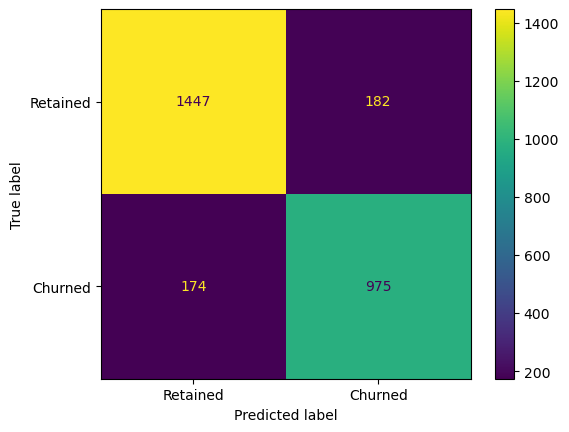

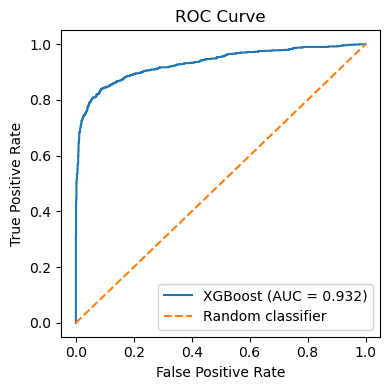

In [110]:
#confusion matrix


plt.figure(figsize=(4,4))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm,
                    display_labels=['Retained', 'Churned']).plot()

#ROC Curve
#  ROC points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

**Model Performance**

* Accuracy: 87.19%: The model correctly classified about 87% of customers as retained or churned.
* Precision: 84.27%: Of the customers predicted to churn, about 84% actually churned.
* Recall: 84.86%: The model identified about 85% of the actual churned customers.
* ROC-AUC: 0.932: The model has a strong ability to distinguish between churned and retained customers across different classification thresholds.

Confusion Matrix: 1,447 retained customers were correctly identified, while 975 churned customers were correctly identified. The model produced 182 false positives and 174 false negatives.

ROC Curve: The AUC of 0.932 indicates strong discrimination, with the curve staying well above the random-classifier line.

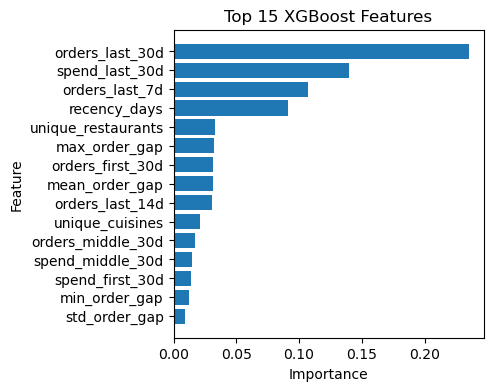

In [84]:
features = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

features = features.sort_values(
    "importance",
    ascending=False
)

top_features = features.head(15).sort_values("importance")

plt.figure(fisize=(4,4))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.show()

## SHAP Analysis

In [9]:
import shap


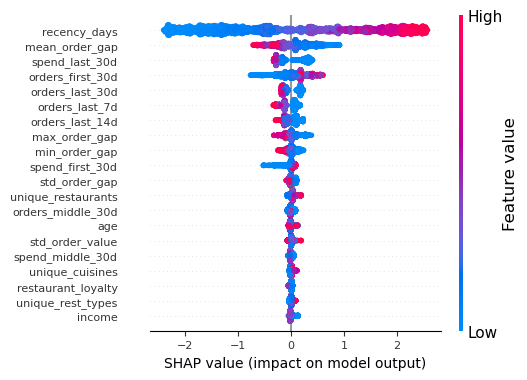

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
plt.figure(figsize=(4,6))
shap.summary_plot(shap_values,
                  X_test,
                  plot_size=(6, 4),
                  show=False
                 )
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
ax = plt.gca()
ax.xaxis.label.set_size(10)
plt.show()



Recency was calculated as the number of days since the customer's last order during the observation period. It was calculated using only information available up to day 90 to avoid temporal leakage.

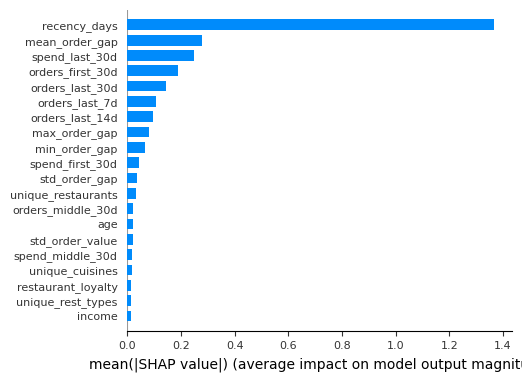

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
plt.figure(figsize=(4,6))
shap.summary_plot(shap_values,
                  X_test,
                  plot_type="bar",
                  plot_size=(6, 4),
                  show=False
                 )
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
ax = plt.gca()
ax.xaxis.label.set_size(10)
plt.savefig("../images/shap_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

